# Customer Churn

<a target="_blank" href="https://colab.research.google.com/github/LuisAngelMendozaVelasco/luisangelmendozavelasco.github.io/blob/master/_portfolio/IBM_Introduction_to_Machine_Learning_Specialization/portfolio-2.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png">Run in Google Colab</a>

**Objective**: Train a k-Nearest Neighbors (k-NN) classifier to predict customer churn.

## Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

sns.set_style(style="whitegrid")

## Load the dataset

In [2]:
file_url = "https://raw.githubusercontent.com/LuisAngelMendozaVelasco/IBM_Introduction_to_Machine_Learning_Specialization/refs/heads/main/Supervised_Machine_Learning-Classification/Week2/Labs/data/churndata.pkl"
df = pd.read_pickle(file_url)
df.head()

,id,months,offer,phone,multiple,internet_type,gb_mon,security,backup,protection,...,unlimited,contract,paperless,payment,monthly,total_revenue,satisfaction,churn_value,churn_score,cltv
0,8779-QRDMV,1,None,No,No,DSL,8,No,No,Yes,...,No,Month-to-Month,Yes,Bank Withdrawal,39.65,59.65,3,1,91,5433
1,7495-OOKFY,8,Offer E,Yes,Yes,Fiber Optic,17,No,Yes,No,...,Yes,Month-to-Month,Yes,Credit Card,80.65,1024.10,3,1,69,5302
2,1658-BYGOY,18,Offer D,Yes,Yes,Fiber Optic,52,No,No,No,...,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1910.88,2,1,81,3179
3,4598-XLKNJ,25,Offer C,Yes,No,Fiber Optic,12,No,Yes,Yes,...,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2995.07,2,1,88,5337
4,4846-WHAFZ,37,Offer C,Yes,Yes,Fiber Optic,14,No,No,No,...,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,3102.36,2,1,67,2793


## Understand the dataset

We use a customer churn dataset from a fictional telecom firm which includes customer data, usage of long-distance, data usage, monthly revenue, type of offerings, and other services purchased by customers. The data include a mix of numeric, categorical, and ordinal variables that will be used to predict customer churn rates.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             7043 non-null   object 
 1   months         7043 non-null   int64  
 2   offer          7043 non-null   object 
 3   phone          7043 non-null   object 
 4   multiple       7043 non-null   object 
 5   internet_type  7043 non-null   object 
 6   gb_mon         7043 non-null   int64  
 7   security       7043 non-null   object 
 8   backup         7043 non-null   object 
 9   protection     7043 non-null   object 
 10  support        7043 non-null   object 
 11  unlimited      7043 non-null   object 
 12  contract       7043 non-null   object 
 13  paperless      7043 non-null   object 
 14  payment        7043 non-null   object 
 15  monthly        7043 non-null   float64
 16  total_revenue  7043 non-null   float64
 17  satisfaction   7043 non-null   int64  
 18  churn_value  

## Visualize the dataset

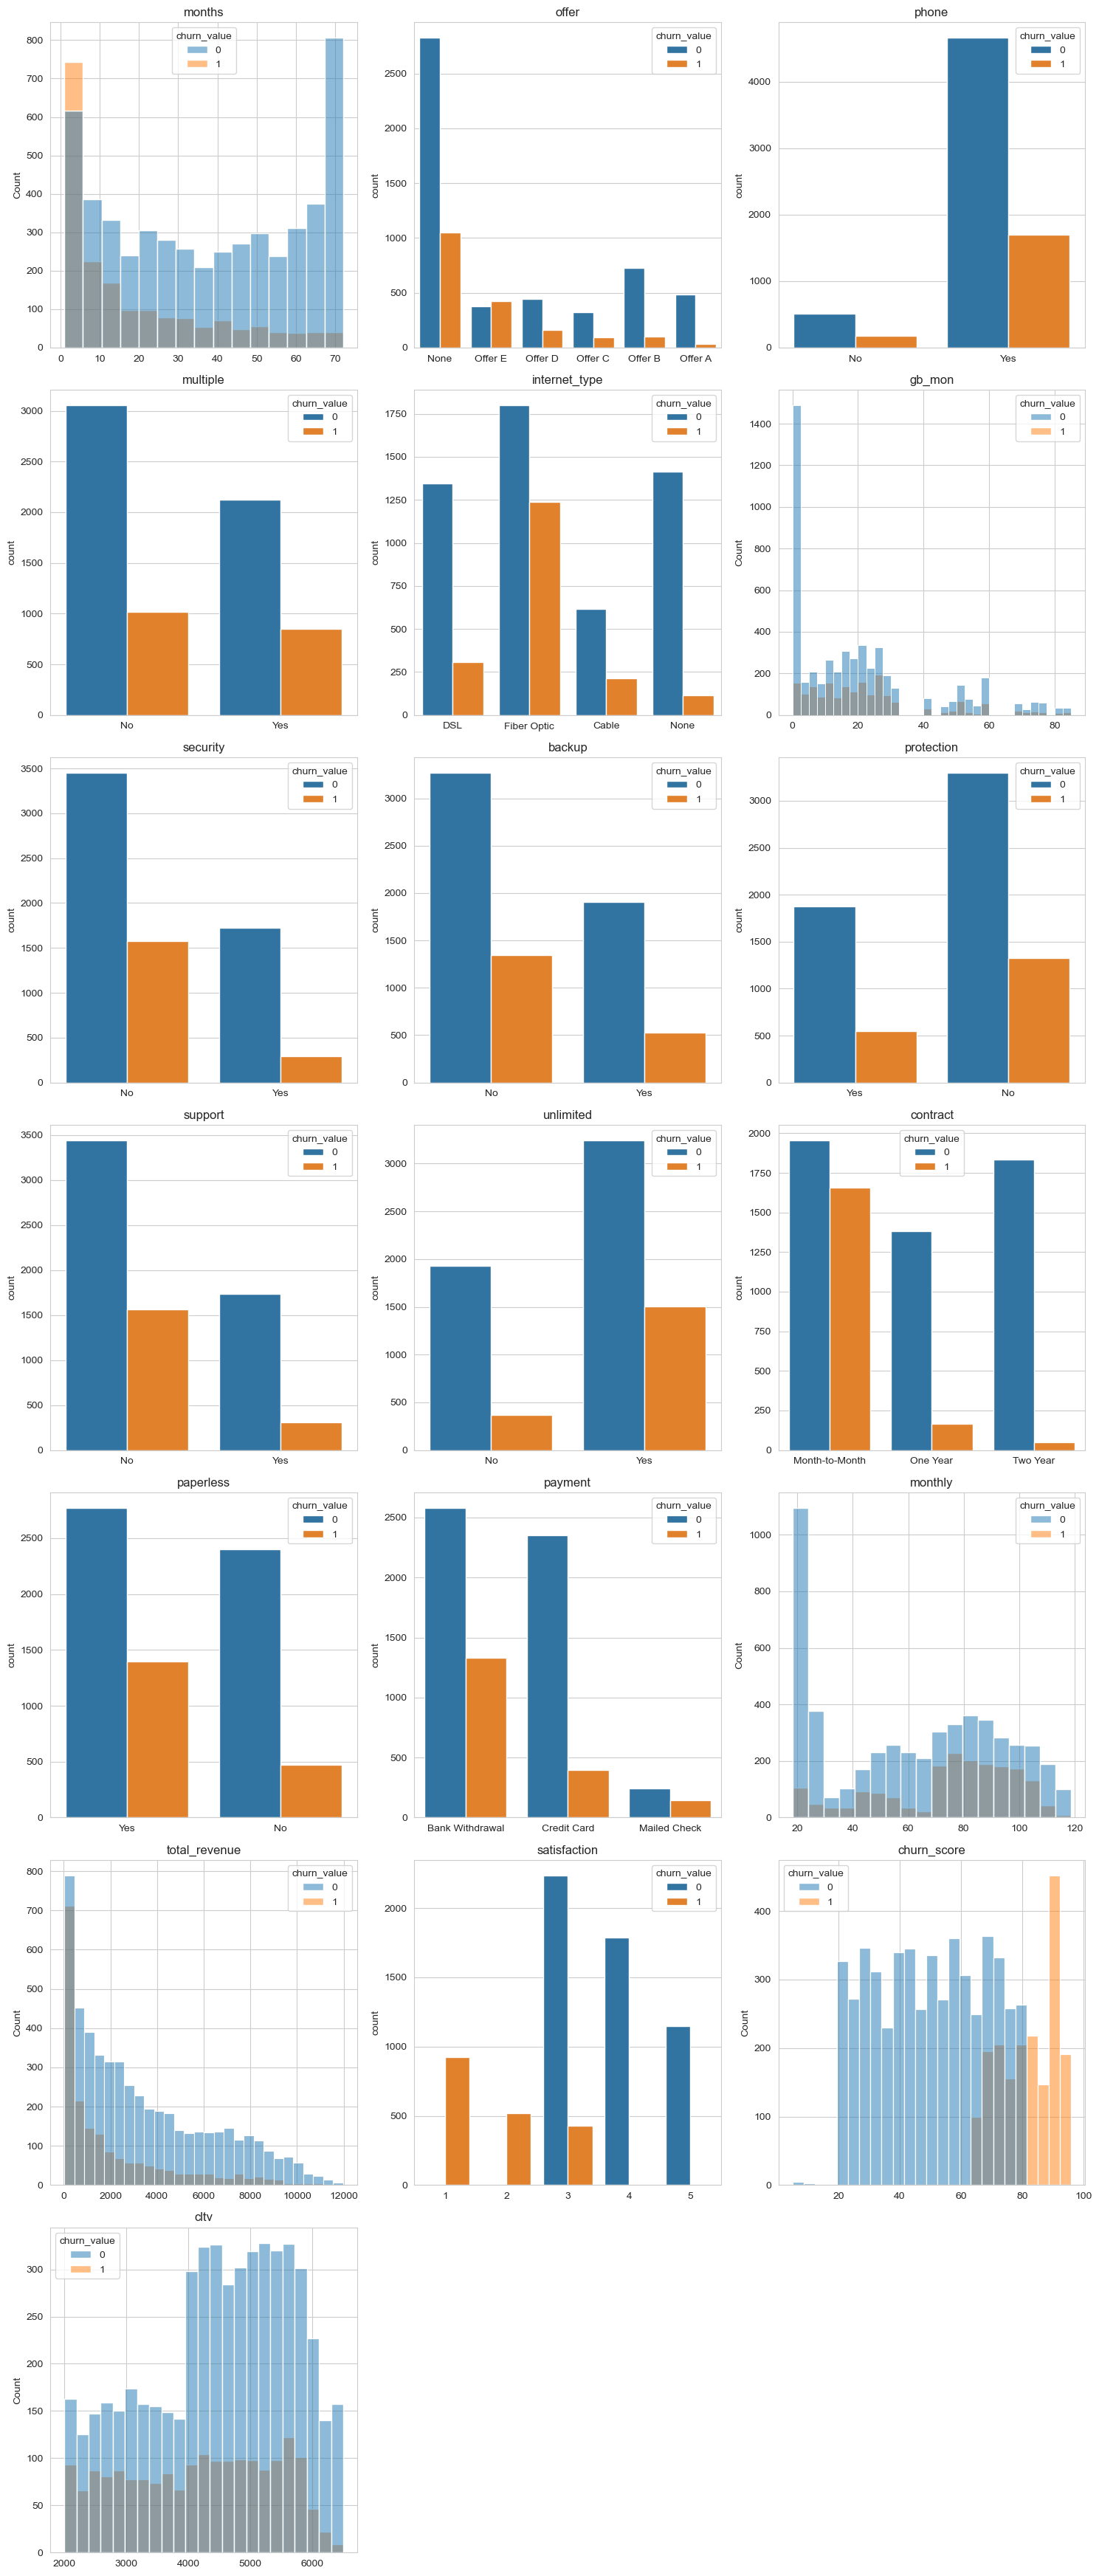

In [4]:
number_features = df.shape[1] - 2
grid_rows = int(np.ceil(number_features / 3))
fig, axs = plt.subplots(grid_rows, 3, figsize=(15, 5 * grid_rows))

for ax, feature in zip(axs.flatten(), df.drop(columns=["id", "churn_value"]).columns):
    if df[feature].dtype == 'O':
        sns.countplot(data=df, x=feature, hue="churn_value", ax=ax)
        ax.set_xlabel("")
        ax.set_title(feature)
    elif len(df[feature].unique()) <= 10:
        sns.countplot(data=df, x=feature, hue="churn_value", ax=ax)
        ax.set_xlabel("")
        ax.set_title(feature)
    else:
        sns.histplot(data=df, x=feature, hue="churn_value", ax=ax)
        ax.set_xlabel("")
        ax.set_title(feature)

for ax in axs.flatten()[number_features:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Visualize the class distribution

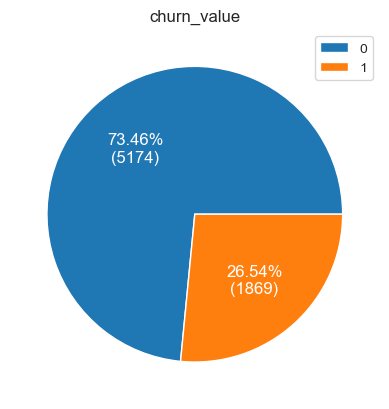

In [5]:
target_feature = "churn_value"
labels, sizes = np.unique(df[target_feature], return_counts=True)

fig, ax = plt.subplots()
ax.pie(sizes, textprops={'color': "w", 'fontsize': '12'}, autopct=lambda pct: "{:.2f}%\n({:d})".format(pct, round(pct/100 * sum(sizes))))
ax.legend([i for i in labels])
ax.set_title(target_feature)
plt.show()

## Preprocess the dataset

In [6]:
preprocessed_df = df.drop(columns=["id"])
scaler = StandardScaler()

for feature in preprocessed_df.drop(columns=["churn_value", "satisfaction"]).columns:
    if preprocessed_df[feature].dtype in ["int64", "float64"]:
        preprocessed_df[feature] = scaler.fit_transform(preprocessed_df[feature].to_numpy().reshape(-1, 1))

preprocessed_df = pd.get_dummies(preprocessed_df, drop_first=True)
preprocessed_df.head()

,months,gb_mon,monthly,total_revenue,satisfaction,churn_value,churn_score,cltv,offer_Offer A,offer_Offer B,...,security_Yes,backup_Yes,protection_Yes,support_Yes,unlimited_Yes,contract_One Year,contract_Two Year,paperless_Yes,payment_Credit Card,payment_Mailed Check
0,-1.278988,-0.612975,-0.834611,-1.038299,3,1,1.535060,0.872974,False,False,...,False,False,True,False,False,False,False,True,False,False
1,-0.993743,-0.172176,0.528063,-0.701668,3,1,0.495781,0.762236,False,False,...,False,True,False,False,True,False,False,True,True,False
2,-0.586250,1.542040,1.019955,-0.392146,2,1,1.062661,-1.032395,False,False,...,False,False,False,False,True,False,False,True,False,False
3,-0.301005,-0.417064,1.121324,-0.013720,2,1,1.393340,0.791822,False,False,...,False,True,True,False,True,False,False,True,False,False
4,0.187986,-0.319109,0.390134,0.023728,2,1,0.401301,-1.358692,False,False,...,False,False,False,False,True,False,False,True,False,False


## Split the dataset into train and test subsets

In [7]:
X = preprocessed_df.drop(columns=[target_feature])
y = preprocessed_df[target_feature]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5282, 27)
X_test shape: (1761, 27)


## Train a k-NN classifier

In [8]:
n_neighbors = range(2, 52, 2)
parameters = {'n_neighbors': n_neighbors}

knn_classifier = KNeighborsClassifier()
clf = GridSearchCV(knn_classifier, parameters, scoring='recall')
clf.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': range(2, 52, 2)}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,34


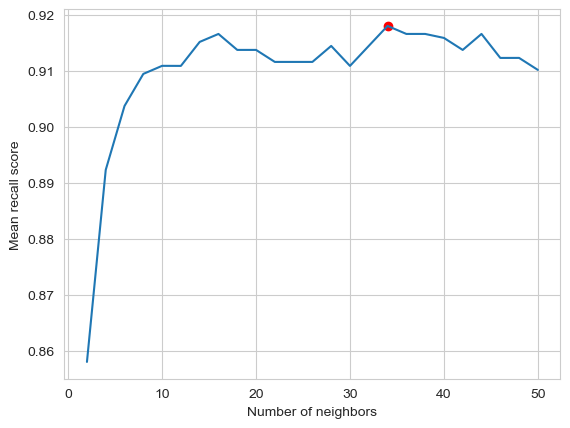

In [9]:
plt.figure()
plt.plot(n_neighbors, clf.cv_results_['mean_test_score'])
plt.scatter(clf.best_params_['n_neighbors'], clf.best_score_, color='red')
plt.xlabel("Number of neighbors")
plt.ylabel("Mean recall score")
plt.show()

## Evaluate the k-NN classifier

              precision    recall  f1-score   support

           0     0.9732    0.9822    0.9777      1294
           1     0.9495    0.9251    0.9371       467

    accuracy                         0.9671      1761
   macro avg     0.9613    0.9536    0.9574      1761
weighted avg     0.9669    0.9671    0.9669      1761



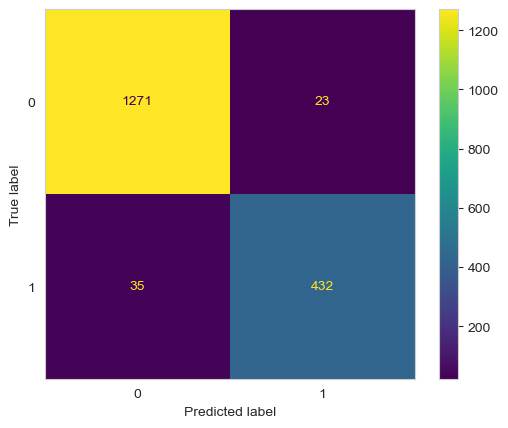

In [10]:
y_pred = clf.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.grid(False)
plt.show()